In [34]:
from nba_api.stats.static import teams
import pandas as pd

# Get all NBA teams
nba_teams = teams.get_teams()

# Convert to DataFrame for easy viewing
teams_df = pd.DataFrame(nba_teams)

# Display the DataFrame ordered by year_founded
# teams_df = teams_df.sort_values(by='year_founded', ascending=True)
# teams_df = teams_df.reset_index(drop=True)
# create column called ID where ID = last 2 digits of the team_id
teams_df['ID'] = teams_df['id'].astype(str).str[-2:]
display(teams_df)


,id,full_name,abbreviation,nickname,city,state,year_founded,ID
0,1610612737,Atlanta Hawks,ATL,Hawks,Atlanta,Georgia,1949,37
1,1610612738,Boston Celtics,BOS,Celtics,Boston,Massachusetts,1946,38
2,1610612739,Cleveland Cavaliers,CLE,Cavaliers,Cleveland,Ohio,1970,39
3,1610612740,New Orleans Pelicans,NOP,Pelicans,New Orleans,Louisiana,2002,40
4,1610612741,Chicago Bulls,CHI,Bulls,Chicago,Illinois,1966,41
5,1610612742,Dallas Mavericks,DAL,Mavericks,Dallas,Texas,1980,42
6,1610612743,Denver Nuggets,DEN,Nuggets,Denver,Colorado,1976,43
7,1610612744,Golden State Warriors,GSW,Warriors,Golden State,California,1946,44
8,1610612745,Houston Rockets,HOU,Rockets,Houston,Texas,1967,45
9,1610612746,Los Angeles Clippers,LAC,Clippers,Los Angeles,California,1970,46


In [35]:
# Get matches for a specific team in a specific season
from nba_api.stats.endpoints import teamgamelog
from nba_api.stats.static import teams
import pandas as pd

# Define the abbreviation of the team you want to get data for
abreviation = 'GSW'
# Get the team information using the abbreviation
team = teams.find_team_by_abbreviation(abreviation)
# Get their game log for the specified season
games = teamgamelog.TeamGameLog(
    team_id=team['id'], 
    season='2024-25', 
    season_type_all_star='Playoffs')
# Valid values for season_type_all_star:
# 'Regular Season'
# 'Pre Season'
# 'Playoffs'
# 'PlayIn'
# 'All Star'
# 'In Season Tournament'

# Get the data as a DataFrame
df = games.get_data_frames()[0]
# Display the first few rows of the game log
display(df.head())

,Team_ID,Game_ID,GAME_DATE,MATCHUP,WL,W,L,W_PCT,MIN,FGM,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS
0,1610612744,0042400154,"APR 28, 2025",GSW vs. HOU,None,NaN,NaN,NaN,0,4,...,1.000,0,3,3,3,3,0,0,0,13
1,1610612744,0042400153,"APR 26, 2025",GSW vs. HOU,W,2.0,1.0,0.667,240,39,...,0.800,10,35,45,26,9,6,10,21,104
2,1610612744,0042400152,"APR 23, 2025",GSW @ HOU,L,1.0,1.0,0.500,240,33,...,0.611,7,26,33,22,7,6,15,18,94
3,1610612744,0042400151,"APR 20, 2025",GSW @ HOU,W,1.0,0.0,1.000,240,36,...,0.786,6,30,36,20,14,1,11,18,95


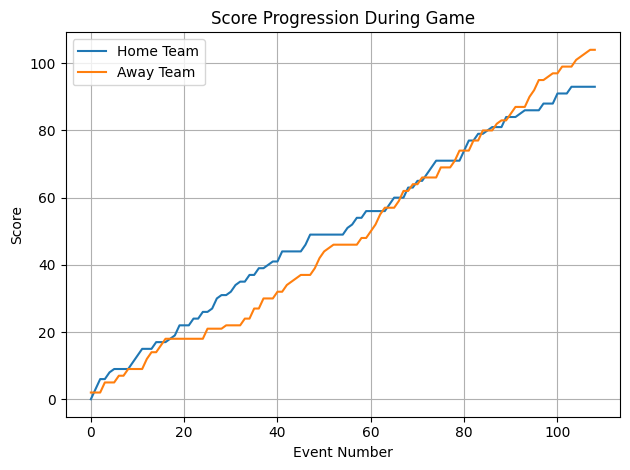

In [36]:
from nba_api.stats.endpoints import playbyplayv2
import matplotlib.pyplot as plt

# Replace this with your actual Game ID
game_id = '0042400153' 

# Get the play-by-play data
pbp = playbyplayv2.PlayByPlayV2(game_id=game_id)
df = pbp.get_data_frames()[0]

# Clean up and keep only plays that change score
df = df[df['SCORE'].notnull()].copy()
df['EventNum'] = range(len(df))

# Split score into team points
df[['HomeScore', 'AwayScore']] = df['SCORE'].str.split(' - ', expand=True).astype(int)

# Plot the score progression
plt.plot(df['EventNum'], df['HomeScore'], label='Home Team')
plt.plot(df['EventNum'], df['AwayScore'], label='Away Team')
plt.xlabel('Event Number')
plt.ylabel('Score')
plt.title('Score Progression During Game')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


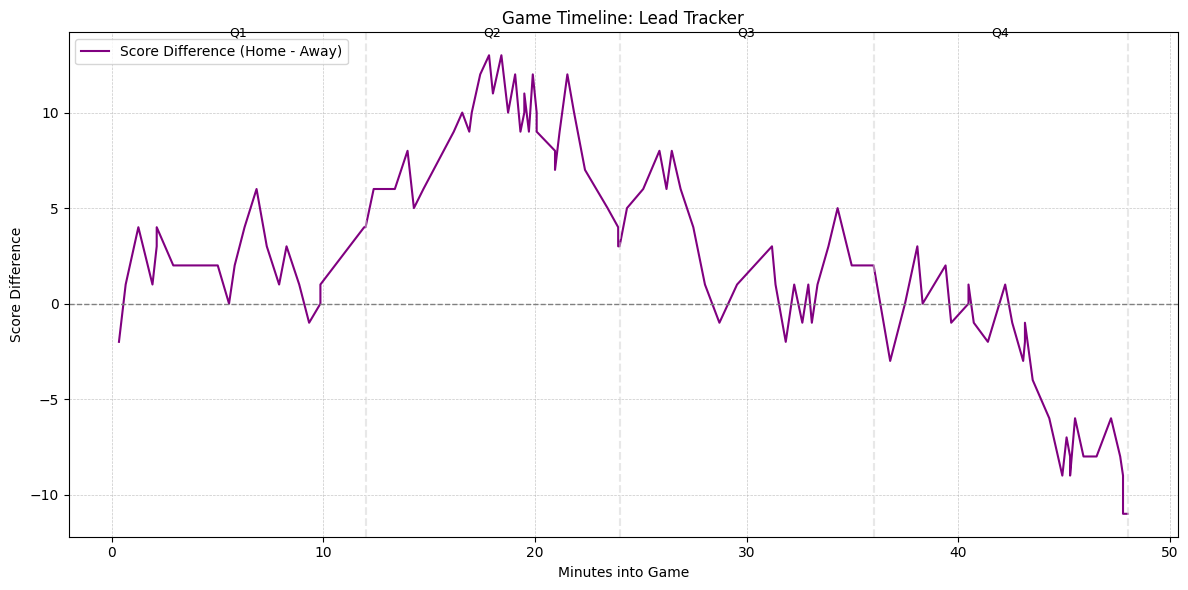

In [37]:
from nba_api.stats.endpoints import playbyplayv2
import matplotlib.pyplot as plt
import pandas as pd

# Load play-by-play data
pbp = playbyplayv2.PlayByPlayV2(game_id=game_id)
df = pbp.get_data_frames()[0]

# Filter rows with actual score updates
df = df[df['SCORE'].notnull()].copy()

# Split score into numeric values
df[['HomeScore', 'AwayScore']] = df['SCORE'].str.split(' - ', expand=True).astype(int)

# Calculate score difference
df['ScoreDiff'] = df['HomeScore'] - df['AwayScore']

# Convert PCTIMESTRING to seconds remaining in period
def time_str_to_seconds(t):
    mins, secs = map(int, t.split(':'))
    return mins * 60 + secs

df['SecondsRemaining'] = df['PCTIMESTRING'].apply(time_str_to_seconds)

# Convert period + time into total minutes from game start
df['GameMinutes'] = (
    (df['PERIOD'] - 1) * 12 + (12 - df['SecondsRemaining'] / 60)
)

# Plot score difference over time
plt.figure(figsize=(12, 6))
plt.plot(df['GameMinutes'], df['ScoreDiff'], label='Score Difference (Home - Away)', color='purple')

# Highlight zero line (tie)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

# Add quarter dividers
for q in range(1, df['PERIOD'].max() + 1):
    plt.axvline(x=q * 12, color='lightgray', linestyle='--', alpha=0.5)
    plt.text(q * 12 - 6, max(df['ScoreDiff']) + 1, f'Q{q}', ha='center', fontsize=9)

# Labels and styling
plt.xlabel('Minutes into Game')
plt.ylabel('Score Difference')
plt.title('Game Timeline: Lead Tracker')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


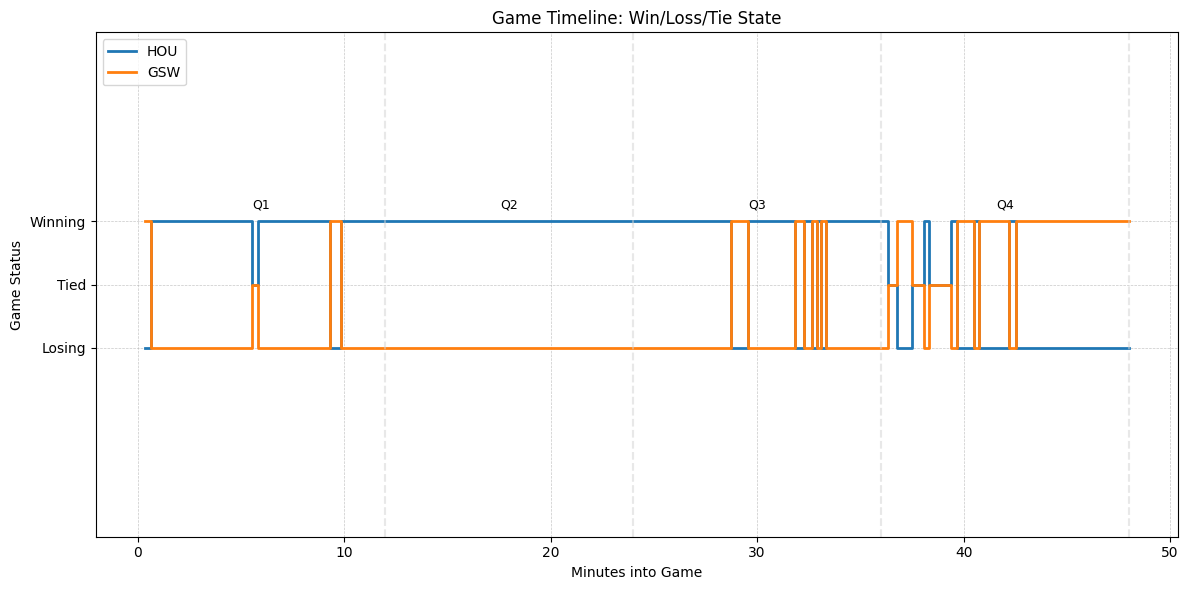

,Local Team,Duration,Percentage
0,Losing,34.17,71.70
2,Winning,11.08,23.26
1,Tied,2.40,5.04


In [38]:
from nba_api.stats.endpoints import playbyplayv2
import matplotlib.pyplot as plt
from nba_api.stats.endpoints import boxscoresummaryv2

# Load play-by-play data
pbp = playbyplayv2.PlayByPlayV2(game_id=game_id)
df = pbp.get_data_frames()[0]

# Fetch metadata
summary = boxscoresummaryv2.BoxScoreSummaryV2(game_id=game_id)
info = summary.get_data_frames()[1] # The second DataFrame contains game info

away_team_abbr = info.iloc[0]['TEAM_ABBREVIATION']
home_team_abbr = info.iloc[1]['TEAM_ABBREVIATION']

# Keep only scoring plays
df = df[df['SCORE'].notnull()].copy()

# Split scores
df[['AwayScore', 'HomeScore']] = df['SCORE'].str.split(' - ', expand=True).astype(int)

# Calculate game status for each team
def game_state(home, away):
    if home > away:
        return 1, -1
    elif home < away:
        return -1, 1
    else:
        return 0, 0

states = df.apply(lambda row: game_state(row['HomeScore'], row['AwayScore']), axis=1)
df['HomeState'], df['AwayState'] = zip(*states)

# Use game minutes as x-axis
# Convert PCTIMESTRING to seconds remaining in the period
def time_str_to_seconds(t):
    mins, secs = map(int, t.split(':'))
    return mins * 60 + secs

df['SecondsRemaining'] = df['PCTIMESTRING'].apply(time_str_to_seconds)

# Calculate GameMinutes
df['GameMinutes'] = (df['PERIOD'] - 1) * 12 + (12 - df['SecondsRemaining'] / 60)

# Plot binary game state timeline
plt.figure(figsize=(12, 6))
plt.step(df['GameMinutes'], df['AwayState'], where='post', label=away_team_abbr, linewidth=2)
plt.step(df['GameMinutes'], df['HomeState'], where='post', label=home_team_abbr, linewidth=2)

# Add quarter dividers
for q in range(1, df['PERIOD'].max() + 1):
    plt.axvline(x=q * 12, color='lightgray', linestyle='--', alpha=0.5)
    plt.text(q * 12 - 6, 1.2, f'Q{q}', ha='center', fontsize=9)

# Format axes
plt.yticks([-1, 0, 1], ['Losing', 'Tied', 'Winning'])
y=4
plt.ylim(-y, y)
plt.xlabel('Minutes into Game')
plt.ylabel('Game Status')
plt.title('Game Timeline: Win/Loss/Tie State')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Calculate time differences between play events
df['NextMinute'] = df['GameMinutes'].shift(-1)
df['Duration'] = df['NextMinute'] - df['GameMinutes']

# Drop the last row (no duration to next event)
df = df.dropna(subset=['Duration'])

# Sum up time spent in each state
state_time = df.groupby('HomeState')['Duration'].sum().reset_index()

# Map state values to readable labels
state_labels = {1: 'Winning', 0: 'Tied', -1: 'Losing'}
state_time['Local Team'] = state_time['HomeState'].map(state_labels)
state_time = state_time[['Local Team', 'Duration']].sort_values(by='Duration', ascending=False)

# Calculate total time
total_time = state_time['Duration'].sum()

# Add percentage column
state_time['Percentage'] = (state_time['Duration'] / total_time * 100).round(2)

# Round durations to 2 decimal places (minutes)
state_time['Duration'] = state_time['Duration'].round(2)

# Display the final table
display(state_time)



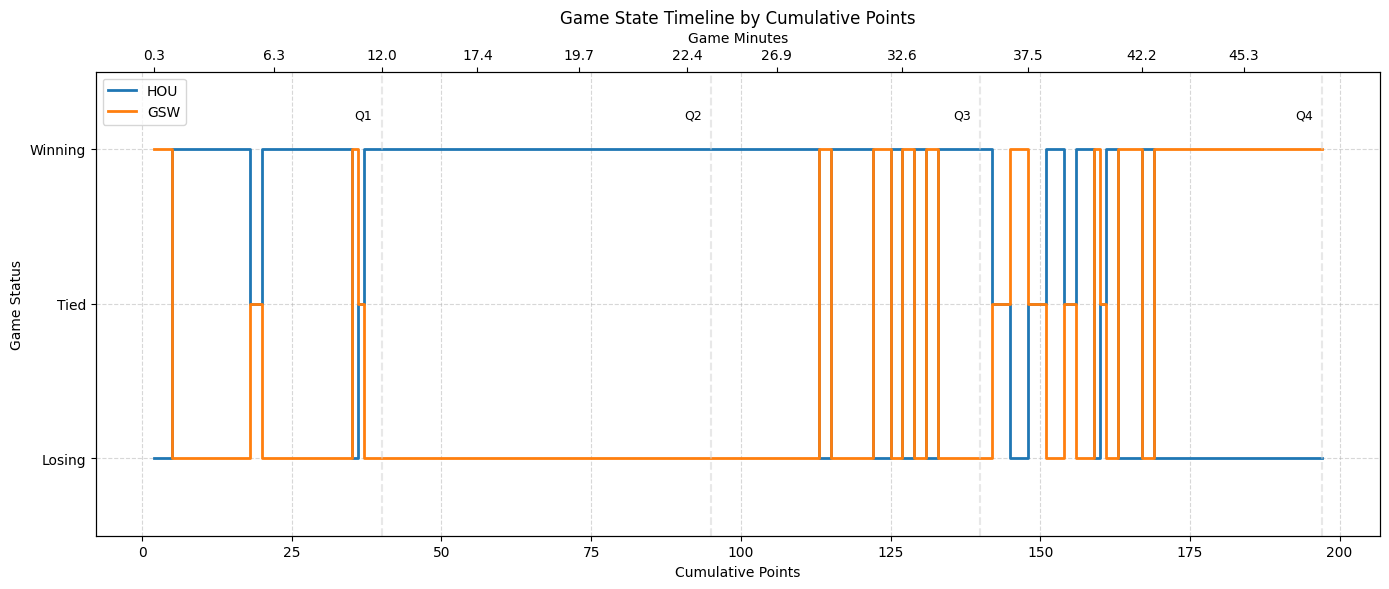

,Local Team,Duration,Percentage
0,Losing,34.17,71.70
2,Winning,11.08,23.26
1,Tied,2.40,5.04


In [39]:
from nba_api.stats.endpoints import playbyplayv2, boxscoresummaryv2
import matplotlib.pyplot as plt
import pandas as pd

# Load play-by-play data
pbp = playbyplayv2.PlayByPlayV2(game_id=game_id)
df = pbp.get_data_frames()[0]

# Fetch game summary for team names
summary = boxscoresummaryv2.BoxScoreSummaryV2(game_id=game_id)
info = summary.get_data_frames()[1]
away_team_abbr = info.iloc[0]['TEAM_ABBREVIATION']
home_team_abbr = info.iloc[1]['TEAM_ABBREVIATION']

# Keep only scoring plays
df = df[df['SCORE'].notnull()].copy()

# Split scores into integers
df[['AwayScore', 'HomeScore']] = df['SCORE'].str.split(' - ', expand=True).astype(int)

# Define game state per team
def game_state(home, away):
    if home > away:
        return 1, -1
    elif home < away:
        return -1, 1
    else:
        return 0, 0

states = df.apply(lambda row: game_state(row['HomeScore'], row['AwayScore']), axis=1)
df['HomeState'], df['AwayState'] = zip(*states)

# Convert time string to total game minutes
def time_str_to_seconds(t):
    mins, secs = map(int, t.split(':'))
    return mins * 60 + secs

df['SecondsRemaining'] = df['PCTIMESTRING'].apply(time_str_to_seconds)
df['GameMinutes'] = (df['PERIOD'] - 1) * 12 + (12 - df['SecondsRemaining'] / 60)

# Add cumulative points column for plotting
df['CumulativePoints'] = df['HomeScore'] + df['AwayScore']

# --- PLOTTING ---
fig, ax1 = plt.subplots(figsize=(14, 6))

# Step plot: cumulative points vs game state
ax1.step(df['CumulativePoints'], df['AwayState'], where='post', label=away_team_abbr, linewidth=2)
ax1.step(df['CumulativePoints'], df['HomeState'], where='post', label=home_team_abbr, linewidth=2)

# Style Y-axis
ax1.set_yticks([-1, 0, 1])
ax1.set_yticklabels(['Losing', 'Tied', 'Winning'])
ax1.set_ylabel('Game Status')
ax1.set_ylim(-1.5, 1.5)

# Bottom X-axis: cumulative points
ax1.set_xlabel('Cumulative Points')

# Add grid and legend
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# Top X-axis: game minutes with quarter annotations
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())

# Find approximate matching point ticks for top axis
point_to_minute = dict(zip(df['CumulativePoints'], df['GameMinutes']))
tick_points = sorted(set(df['CumulativePoints']))[::len(df)//12]  # ~12 ticks
tick_minutes = [round(point_to_minute.get(p, 0), 1) for p in tick_points]

ax2.set_xticks(tick_points)
ax2.set_xticklabels(tick_minutes)
ax2.set_xlabel('Game Minutes')

# Add quarter dividers
for q in range(1, df['PERIOD'].max() + 1):
    max_points = df[df['PERIOD'] == q]['CumulativePoints'].max()
    ax1.axvline(x=max_points, color='lightgray', linestyle='--', alpha=0.5)
    ax1.text(max_points - 3, 1.2, f'Q{q}', ha='center', fontsize=9)

plt.title('Game State Timeline by Cumulative Points')
plt.tight_layout()
plt.show()

# --- STATS TABLE (time spent in states for home team) ---
# Calculate time spent in each state using GameMinutes
df['NextGameMinute'] = df['GameMinutes'].shift(-1)
df['Duration'] = df['NextGameMinute'] - df['GameMinutes']
df = df.dropna(subset=['Duration'])

# Group durations by state
state_time = df.groupby('HomeState')['Duration'].sum().reset_index()

# Label states
state_labels = {1: 'Winning', 0: 'Tied', -1: 'Losing'}
state_time['Local Team'] = state_time['HomeState'].map(state_labels)
state_time = state_time[['Local Team', 'Duration']].sort_values(by='Duration', ascending=False)

# Add percentages
total_time = state_time['Duration'].sum()
state_time['Percentage'] = (state_time['Duration'] / total_time * 100).round(2)
state_time['Duration'] = state_time['Duration'].round(2)

# Display table
display(state_time)


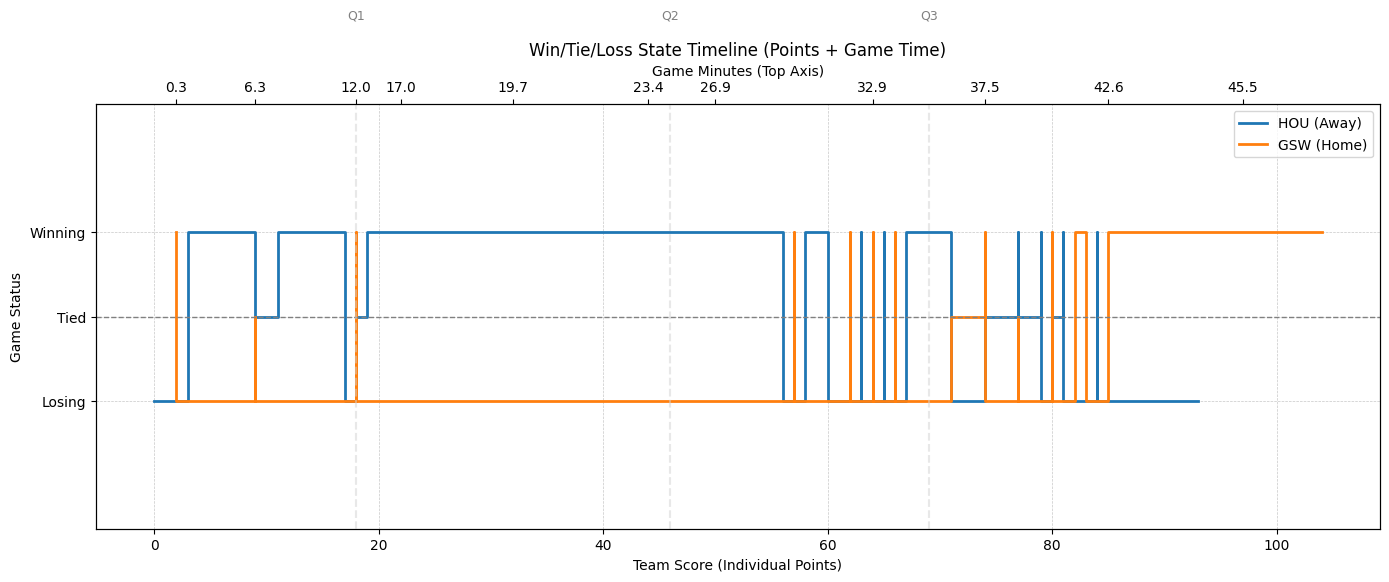

,HomeTeam,Minutes,Percentage
0,Losing,34.17,71.71
1,Tied,2.40,5.04
2,Winning,11.08,23.25


In [40]:
from nba_api.stats.endpoints import playbyplayv2, boxscoresummaryv2
import matplotlib.pyplot as plt
import pandas as pd

# Load play-by-play data
pbp = playbyplayv2.PlayByPlayV2(game_id=game_id)
df = pbp.get_data_frames()[0]

# Fetch metadata for team abbreviations
summary = boxscoresummaryv2.BoxScoreSummaryV2(game_id=game_id)
info = summary.get_data_frames()[1]

away_team_abbr = info.iloc[0]['TEAM_ABBREVIATION']
home_team_abbr = info.iloc[1]['TEAM_ABBREVIATION']

# Keep only rows with score updates
df = df[df['SCORE'].notnull()].copy()

# Split and parse scores
df[['AwayScore', 'HomeScore']] = df['SCORE'].str.split(' - ', expand=True).astype(int)

# Calculate score states per team
def game_state(away, home):
    if home < away:
        return 1, -1
    elif home > away:
        return -1, 1
    else:
        return 0, 0

df['AwayState'], df['HomeState']= zip(*df.apply(lambda row: game_state(row['AwayScore'],row['HomeScore']), axis=1))


# Convert PCTIMESTRING + PERIOD to actual game minutes
def time_str_to_seconds(t):
    mins, secs = map(int, t.split(':'))
    return mins * 60 + secs

df['SecondsRemaining'] = df['PCTIMESTRING'].apply(time_str_to_seconds)
df['GameMinutes'] = (df['PERIOD'] - 1) * 12 + (12 - df['SecondsRemaining'] / 60)

# Track how long each state lasted
df['NextGameMinute'] = df['GameMinutes'].shift(-1)
df['Duration'] = df['NextGameMinute'] - df['GameMinutes']
df = df.dropna(subset=['Duration'])

# Plotting setup
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bottom X-axis: Team points
ax1.step(df['AwayScore'], df['AwayState'], where='post', label=f'{away_team_abbr} (Away)', linewidth=2)
ax1.step(df['HomeScore'], df['HomeState'], where='post', label=f'{home_team_abbr} (Home)', linewidth=2)
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)

# Y-axis: Game status
ax1.set_yticks([-1, 0, 1])
y=2.5
plt.ylim(-y, y)
ax1.set_yticklabels(['Losing', 'Tied', 'Winning'])
ax1.set_ylabel('Game Status')

# X-axis (bottom): Team score
ax1.set_xlabel('Team Score (Individual Points)')
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax1.legend(loc='best')

# Top X-axis: Game time in minutes
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
tick_positions = df['HomeScore']
tick_labels = df['GameMinutes'].round(1)
ax2.set_xticks(tick_positions[::len(tick_positions)//10])  # Reduce label density
ax2.set_xticklabels(tick_labels[::len(tick_labels)//10])
ax2.set_xlabel('Game Minutes (Top Axis)')

# Add quarter dividers on top axis
for q in range(1, df['PERIOD'].max() + 1):
    minute = q * 12
    score_at_q = df[df['GameMinutes'] >= minute]['HomeScore'].min()
    if pd.notna(score_at_q):
        ax2.axvline(x=score_at_q, color='lightgray', linestyle='--', alpha=0.5)
        ax2.text(score_at_q, 1.2, f'Q{q}', ha='center', fontsize=9, color='gray', transform=ax1.get_xaxis_transform())

plt.title('Win/Tie/Loss State Timeline (Points + Game Time)')
plt.tight_layout()
plt.show()

# Create state duration summary for the home team
state_labels = {1: 'Winning', 0: 'Tied', -1: 'Losing'}
home_state_minutes = df.groupby('HomeState')['Duration'].sum().reset_index()
home_state_minutes['HomeTeam'] = home_state_minutes['HomeState'].map(state_labels)
home_state_minutes['Minutes'] = home_state_minutes['Duration'].round(2)
home_state_minutes['Percentage'] = (home_state_minutes['Minutes'] / home_state_minutes['Minutes'].sum() * 100).round(2)
home_state_minutes = home_state_minutes[['HomeTeam', 'Minutes', 'Percentage']]

# Display table
display(home_state_minutes)


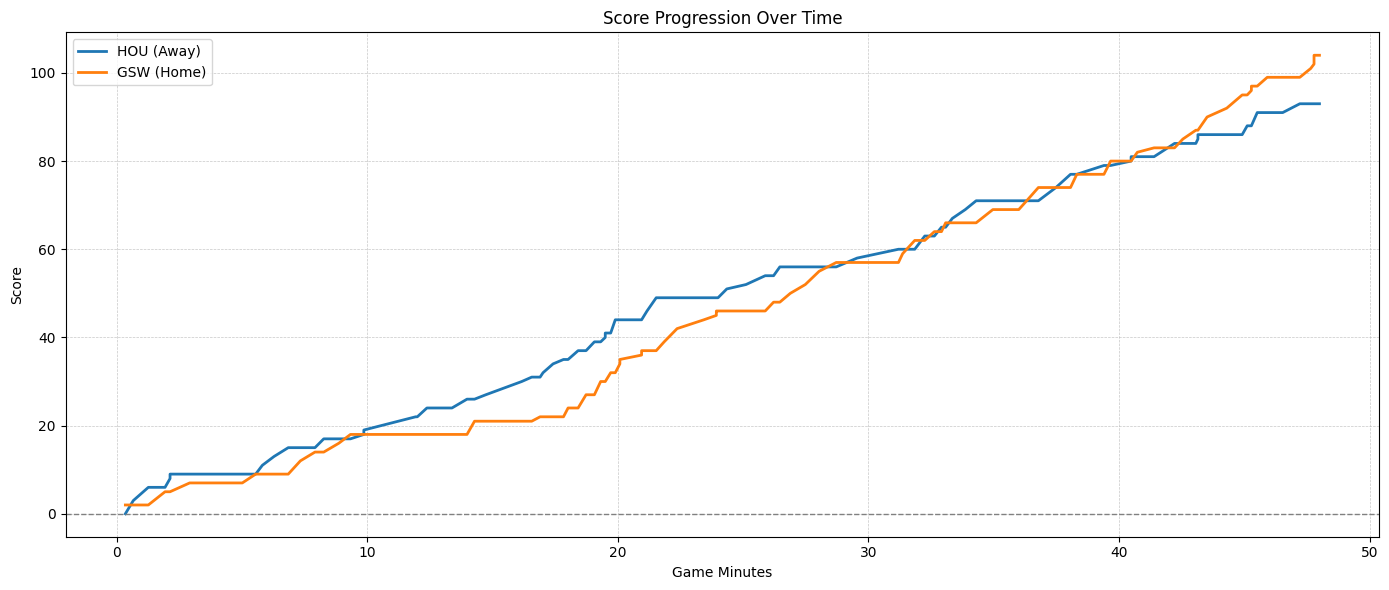

In [41]:
# Plot the points scored by each team over time

import matplotlib.pyplot as plt
from nba_api.stats.endpoints import playbyplayv2, boxscoresummaryv2

# Load play-by-play data
pbp = playbyplayv2.PlayByPlayV2(game_id=game_id)
df = pbp.get_data_frames()[0]
# Fetch metadata for team abbreviations
summary = boxscoresummaryv2.BoxScoreSummaryV2(game_id=game_id)
info = summary.get_data_frames()[1]
away_team_abbr = info.iloc[0]['TEAM_ABBREVIATION']
home_team_abbr = info.iloc[1]['TEAM_ABBREVIATION']
# Keep only rows with score updates
df = df[df['SCORE'].notnull()].copy()
# Split and parse scores
df[['AwayScore', 'HomeScore']] = df['SCORE'].str.split(' - ', expand=True).astype(int)

# Calculate GameMinutes
def time_str_to_seconds(t):
	mins, secs = map(int, t.split(':'))
	return mins * 60 + secs

df['SecondsRemaining'] = df['PCTIMESTRING'].apply(time_str_to_seconds)
df['GameMinutes'] = (df['PERIOD'] - 1) * 12 + (12 - df['SecondsRemaining'] / 60)
plt.figure(figsize=(14, 6))
plt.plot(df['GameMinutes'], df['AwayScore'], label=f'{away_team_abbr} (Away)', linewidth=2)
plt.plot(df['GameMinutes'], df['HomeScore'], label=f'{home_team_abbr} (Home)', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Game Minutes')
plt.ylabel('Score')
plt.title('Score Progression Over Time')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()
